In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from bin_model import BinomialModel
from options2 import EuropeanCall, EuropeanPut, AmericanPut


def run_hedging_analysis(t_selected, option_obj, model):
    N = model.N
    K = option_obj.K
    
    # obliczanie wartości drzewa i wartości hedingowych 
    opt_tree = option_obj.calc_opt_tree(model)
    delta_tree, alpha_tree = option_obj.price_with_hedging(model)
    stock_tree = model.generate_stock_tree()
    
    # listy do wykresów
    rows = []
    prices, deltas, alphas = [], [], []

    # wyciągnięcie wartości 
    s_step = stock_tree.get_step(t_selected)
    v_step = opt_tree.get_step(t_selected)
    
    # liczenie delty i alfy tylko dla czasu przedostatniego węzła, bo w czasie N nie ma już hedgingu
    has_hedge = t_selected < N
    if has_hedge:
        d_step = delta_tree.get_step(t_selected)
        a_step = alpha_tree.get_step(t_selected)

    for i in range(t_selected + 1):
        s_val = s_step[i]
        v_val = v_step[i]
        
        if has_hedge:
            d_val = d_step[i]
            a_val = a_step[i]
            portfolio_val = d_val * s_val + a_val
            deltas.append(d_val)
            alphas.append(a_val)
        else:
            d_val, a_val, portfolio_val = None, None, v_val
            
        prices.append(s_val)
        rows.append({
            "Węzeł (i,t)": f"({i}, {t_selected})",
            "Cena Akcji S_t": s_val,
            "Wartość Opcji V_t": v_val,
            "Delta": d_val,
            "Alpha": a_val,
            "Portfel Replikujący": portfolio_val
        })
    
    # tworzenie wykresu
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    if has_hedge:
        # Sortowanie dla ładnej linii na wykresie
        sorted_data = sorted(zip(prices, deltas, alphas))
        p_plot, d_plot, a_plot = zip(*sorted_data)
        
        ax1.set_xlabel('Cena Akcji (S_t)')
        ax1.set_ylabel('Delta (Δ)', color='tab:green')
        ax1.plot(p_plot, d_plot, color='tab:green', marker='o', label='Delta')
        ax1.tick_params(axis='y', labelcolor='tab:green')
        
        ax2 = ax1.twinx()
        ax2.set_ylabel('Alpha (α)', color='tab:blue')
        ax2.plot(p_plot, a_plot, color='tab:blue', marker='s', linestyle='--', label='Alpha')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc='best')
    else:
        ax1.text(0.5, 0.5, "Wygaśnięcie (t=N)\nBrak Delty i Alphy", ha='center', va='center', fontsize=12)

    ax1.axvline(K, color='red', linestyle=':', label=f'Strike K={K}')
    ax1.set_title(f"{option_obj.__class__.__name__} - Portfel Replikujący (Krok {t_selected})")
    ax1.grid(True, alpha=0.2)
    
    plt.tight_layout()
    display(fig)
    plt.close(fig)

    # 4. Tabela
    df = pd.DataFrame(rows)
    return df



# funkcje do wykresu 
def analyze_european_call(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, EuropeanCall(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))

def analyze_european_put(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, EuropeanPut(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))

def analyze_american_call(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, AmericanCall(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))

def analyze_american_put(t):
    model = BinomialModel(S0, N, dt, u, d, r)
    df = run_hedging_analysis(t, AmericanPut(K), model)
    display(df.style.format(precision=4).background_gradient(subset=['Delta'], cmap='RdYlGn'))



def main_dashboard(option_choice, t):
    if option_choice == 'Euro Call': analyze_european_call(t)
    elif option_choice == 'Euro Put': analyze_european_put(t)
    elif option_choice == 'Amer Call': analyze_american_call(t)
    elif option_choice == 'Amer Put': analyze_american_put(t)


S0, K, T, r, sigma = 50, 48, 2, 0.02, 0.3
N = 24
dt = T/N
u = np.exp(sigma * np.sqrt(dt))
d = 1/u

widgets.interact(
    main_dashboard,
    option_choice=['Euro Call', 'Euro Put', 'Amer Call', 'Amer Put'],
    t=widgets.IntSlider(value=0, min=0, max=N, step=1, description='Krok t:')
);

interactive(children=(Dropdown(description='option_choice', options=('Euro Call', 'Euro Put', 'Amer Call', 'Am…

ZESTAWIENIE 1


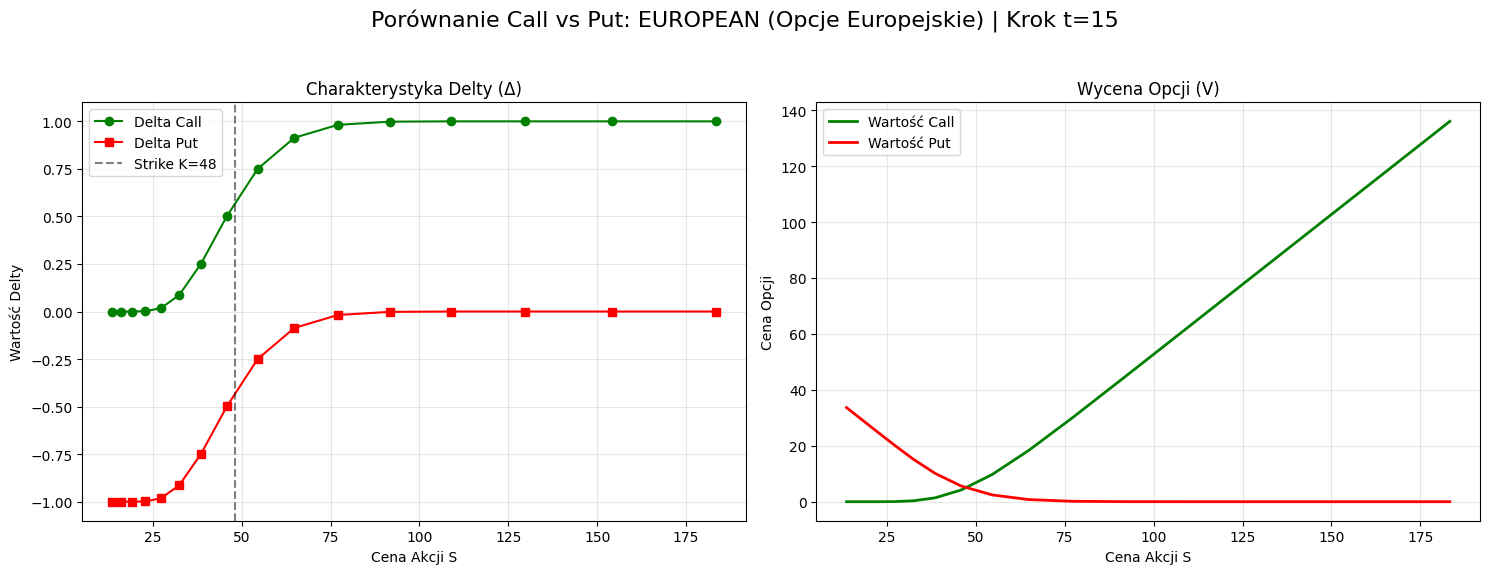


ZESTAWIENIE 2


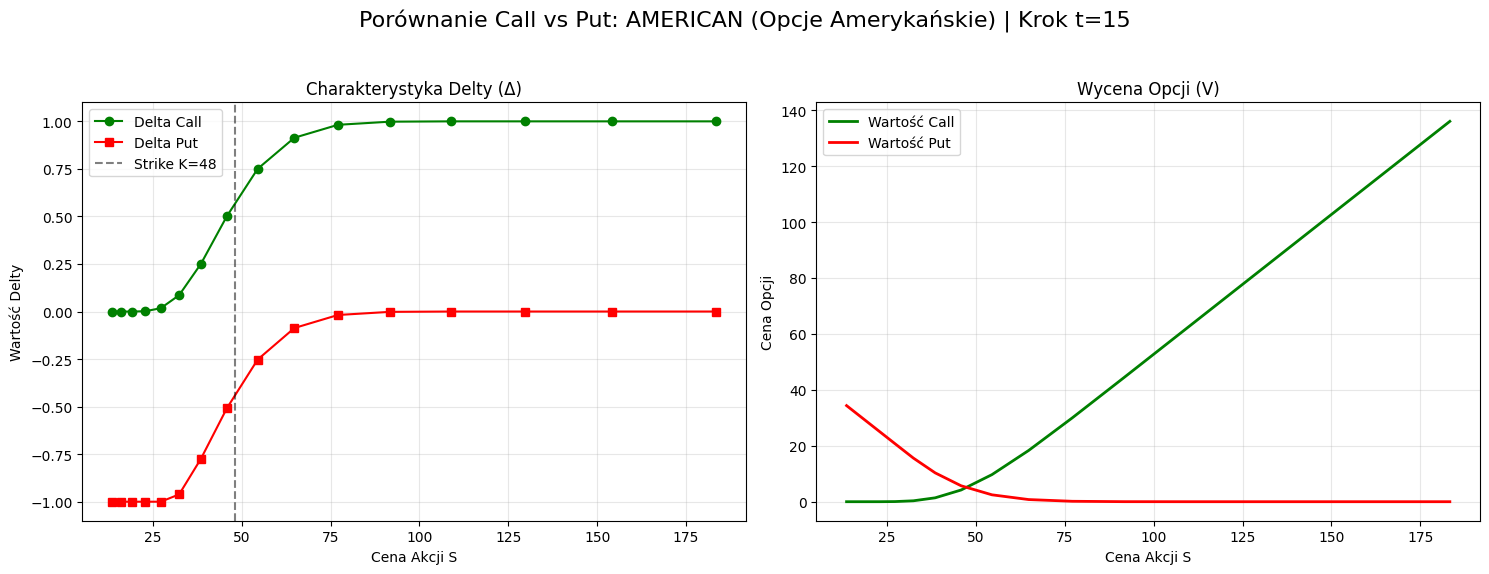

In [25]:
def plot_comparison(t_selected, is_american=False):
    model = BinomialModel(S0, N, dt, u, d, r)
    
    if is_american:
        opt_call = AmericanCall(K)
        opt_put = AmericanPut(K)
        title_suffix = "AMERICAN (Opcje Amerykańskie)"
    else:
        opt_call = EuropeanCall(K)
        opt_put = EuropeanPut(K)
        title_suffix = "EUROPEAN (Opcje Europejskie)"

    # Obliczenia dla obu opcji
    call_tree, call_delta, call_alpha = opt_call.calc_opt_tree(model), *opt_call.price_with_hedging(model)
    put_tree, put_delta, put_alpha = opt_put.calc_opt_tree(model), *opt_put.price_with_hedging(model)
    stock_tree = model.generate_stock_tree()
    
    # Pobranie danych
    S = stock_tree.get_step(t_selected)
    D_call = call_delta.get_step(t_selected)
    D_put = put_delta.get_step(t_selected)
    
    # Sortowanie do wykresu
    idx = np.argsort(S)
    S_plot = S[idx]
    D_call_plot = D_call[idx]
    D_put_plot = D_put[idx]

    # Tworzenie rysunku z dwoma wykresami obok siebie (Delta i Alpha)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f"Porównanie Call vs Put: {title_suffix} | Krok t={t_selected}", fontsize=16)

    # WYKRES 1: DELTA
    ax1.plot(S_plot, D_call_plot, 'g-o', label='Delta Call')
    ax1.plot(S_plot, D_put_plot, 'r-s', label='Delta Put')
    ax1.axvline(K, color='black', linestyle='--', alpha=0.5, label=f'Strike K={K}')
    ax1.set_title("Charakterystyka Delty (Δ)")
    ax1.set_xlabel("Cena Akcji S")
    ax1.set_ylabel("Wartość Delty")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # WYKRES 2: WARTOŚĆ OPCJI V
    V_call_plot = call_tree.get_step(t_selected)[idx]
    V_put_plot = put_tree.get_step(t_selected)[idx]
    
    ax2.plot(S_plot, V_call_plot, 'g-', linewidth=2, label='Wartość Call')
    ax2.plot(S_plot, V_put_plot, 'r-', linewidth=2, label='Wartość Put')
    ax2.set_title("Wycena Opcji (V)")
    ax2.set_xlabel("Cena Akcji S")
    ax2.set_ylabel("Cena Opcji")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- URUCHOMIENIE ---
t_analizy = 15

print("ZESTAWIENIE 1")
plot_comparison(t_analizy, is_american=False)

print("\nZESTAWIENIE 2")
plot_comparison(t_analizy, is_american=True)

# Analiza strategii delta hedgingu dla europejskiej opcji call

## Cel analizy

Delta $\Delta$ to czułość ceny opcji na zmianę ceny instrumentu bazowego.

Celem analizy było zbadanie składu portfela replikującego europejską opcję call w modelu dwumianowym. W każdym węźle drzewa wyznaczono:

- deltę (\(\Delta\)) — liczbę akcji potrzebnych do zabezpieczenia opcji,
- parametr \(\alpha\) — pozycję w aktywie wolnym od ryzyka (gotówka/pożyczka).

---

# Wyznaczenie strategii zabezpieczającej

Dla każdego węzła drzewa rozwiązano układ równań:

$$
\Delta_A S_t^{(B)} + \alpha_A e^{r\Delta t} = V_B
$$

$$
\Delta_A S_t^{(C)} + \alpha_A e^{r\Delta t} = V_C
$$

co prowadzi do wzorów:

$$
\Delta =
\frac{V_{up} - V_{down}}
{S_{up} - S_{down}}
$$

oraz:

$$
\alpha =
\frac{V_{up} - \Delta S_{up}}
{e^{r\Delta t}}
$$

---

# Interpretacja delty

Delta opisuje wrażliwość ceny opcji na zmianę ceny instrumentu bazowego:

$$
\Delta = \frac{\partial V}{\partial S}
$$

Interpretacyjnie:

- \(\Delta = 0.6\) oznacza, że wzrost ceny akcji o 1 jednostkę powoduje wzrost wartości opcji o około 0.6 jednostki,
- delta określa również liczbę akcji potrzebnych do zabezpieczenia jednej wystawionej opcji.

---

# Analiza wykresu delty

Na wykresie można zaobserwować charakterystyczny sigmoidalny kształt funkcji delty.

## 1. Obszar deep out-of-the-money

Dla niskich cen akcji:

$$
S \ll K
$$

delta przyjmuje wartości bliskie zeru.

Oznacza to, że:

- opcja ma niewielkie prawdopodobieństwo wykonania,
- zmiany ceny akcji mają mały wpływ na wartość opcji,
- zabezpieczenie wymaga bardzo małej liczby akcji.

W analizowanym przypadku dla cen akcji około \(20-30\) delta jest bliska zeru.

---

## 2. Obszar w pobliżu ceny wykonania

W pobliżu strike:

$$
S \approx K
$$

delta gwałtownie rośnie.

Jest to obszar największej wrażliwości opcji na zmianę ceny instrumentu bazowego. Niewielka zmiana ceny akcji znacząco wpływa na prawdopodobieństwo wykonania opcji, a tym samym na jej wartość.

W tym obszarze strategia hedgingowa wymaga najczęstszej aktualizacji.

---

## 3. Obszar deep in-the-money

Dla wysokich cen akcji:

$$
S \gg K
$$

delta dąży do wartości 1.

Oznacza to, że:

- opcja zachowuje się niemal identycznie jak akcja,
- zmiana ceny akcji o 1 jednostkę powoduje niemal identyczną zmianę wartości opcji,
- zabezpieczenie wymaga utrzymywania prawie jednej akcji na jedną opcję.

---

# Analiza parametru alpha

Parametr $\alpha$ reprezentuje pozycję w aktywie wolnym od ryzyka.

W analizie wartości $\alpha$ są ujemne, co oznacza:

- konieczność finansowania zakupu akcji poprzez pożyczkę,
- zajmowanie krótkiej pozycji w obligacji/gotówce.

Wraz ze wzrostem ceny akcji:

- delta rośnie,
- konieczne jest utrzymywanie większej liczby akcji,
- rośnie wartość pożyczki,
- parametr $\alpha$ staje się bardziej ujemny.

---


# Wpływ parametrów modelu na deltę

## Wpływ strike \(K\)

Większy strike:

- przesuwa wykres delty w prawo,
- opcja staje się in-the-money dopiero dla większych cen akcji.

---



# Wnioski końcowe

1. Delta europejskiej opcji call przyjmuje wartości z przedziału \([0,1]\).

2. Dla niskich cen akcji opcja jest mało wrażliwa na zmiany rynku, przez co delta jest bliska zeru.

3. W pobliżu ceny wykonania opcja wykazuje największą czułość na zmiany ceny instrumentu bazowego, co objawia się gwałtownym wzrostem delty.

4. Dla wysokich cen akcji delta dąży do 1, ponieważ opcja zachowuje się podobnie do samej akcji.

5. Parametr \(\alpha\) przyjmuje wartości ujemne, co oznacza finansowanie części portfela poprzez pożyczkę.


## Interpretacja wartości czasowej opcji

W analizie delty można również zauważyć wpływ wartości czasowej opcji. Nawet gdy opcja znajduje się out-of-the-money, delta nie jest dokładnie równa zeru. Wynika to z faktu, że przed terminem wygaśnięcia istnieje jeszcze możliwość korzystnej zmiany ceny instrumentu bazowego.

Wartość czasowa jest częścią ceny opcji wynikającą z potencjalnych przyszłych ruchów rynku. Im:
- większa zmienność rynku,
- dłuższy czas do wygaśnięcia,

tym większa szansa, że opcja stanie się in-the-money, a więc większa wartość czasowa opcji.


## Porównanie opcji europejskich i amerykańskich

Na przedstawionych wykresach można zauważyć, że charakterystyki opcji europejskich i amerykańskich są niemal identyczne. Jest to zgodne z teorią wyceny opcji.

W przypadku opcji call na akcję niewypłacającą dywidendy wcześniejsze wykonanie opcji amerykańskiej nie jest optymalne. W rezultacie wartość amerykańskiej opcji call jest równa wartości europejskiej opcji call:

$
C_{American} = C_{European}
$

Powoduje to, że:
- wartości opcji,
- charakterystyki delty,
- strategie zabezpieczające

dla obu typów opcji są praktycznie identyczne.




### 5.2.2 Delta opcji Call



Dla opcji kupna (Call), Delta przyjmuje wartości z przedziału $[0, 1]$. 
* Jest to funkcja rosnąca ceny akcji.
* Wartość $\Delta$ wskazuje, ile akcji należy zakupić (pozycja długa), aby zabezpieczyć jedną wystawioną opcję Call.

* Opcje kupna Far OTM mają deltę bliską 0%, co oznacza niewielką lub zerową wrażliwość na ryzyko związane z akcjami.
* Opcje kupna Far ITM mają deltę bliską 100%, co oznacza, że ​​są przedmiotem obrotu jak akcje.
* Opcje kupna ATM mają deltę około 50%.

### 5.2.3 Delta opcji Put
Dla opcji sprzedaży (Put), Delta przyjmuje wartości z przedziału $[-1, 0]$.
* Jest to funkcja malejąca ceny akcji (wartość staje się mniej ujemna, gdy cena akcji rośnie).
* Ujemny znak oznacza, że w celu zabezpieczenia wystawionej opcji Put należy zająć krótką pozycję w akcjach (sprzedaż akcji).

* Opcje put Far OTM mają deltę bliską 0%, co oznacza brak wrażliwości na akcje.
* Opcje put Far ITM mają deltę bliską -100%, co oznacza, że ​​są przedmiotem obrotu jak krótka pozycja na akcjach.
* Opcje put ATM mają deltę około -50%.

### 5.2.4 Delta jako przybliżone prawdopodobieństwo
W teorii finansów Delta jest często interpretowana jako przybliżone prawdopodobieństwo tego, że opcja wygaśnie "w pieniądzu" (In-the-Money):
* $\Delta \approx 0.5$ sugeruje, że opcja jest At-the-Money (ATM).
* $\Delta \to 1$ (lub $-1$) sugeruje niemal pewne wykonanie opcji.


---

## 5.2.6 Wrażliwość Delty (Delta Sensitivities)



### I. Wrażliwość na czas do wygaśnięcia ($T-t$)
Wraz ze zbliżaniem się terminu wygaśnięcia, zachowanie Delty ulega gwałtownym zmianom:
1. Opcje ITM/OTM: Delta stabilizuje się. Dla opcji będących "w pieniądzu" Delta gwałtownie dąży do $1$ (Call) lub $-1$ (Put). Dla opcji "poza pieniądzem" dąży do $0$.
2. Opcje ATM: Przy cenie akcji bliskiej cenie wykonania ($S \approx K$), Delta staje się ekstremalnie niestabilna tuż przed wygaśnięciem. Nawet minimalny ruch ceny akcji może zmienić Deltę z $0$ na $1$



### II. Wrażliwość na zmienność ($\sigma$)
Zmienność wpływa na wykonania opcji, co przekłada się na nachylenie krzywej Delty:
* Niska zmienność: Wykres Delty jest bardzo stromy w okolicach $K$. Rynek szybko ocenia, czy opcja zostanie wykonana, czy nie.
* Wysoka zmienność:** Wykres Delty ulega "wypłaszczeniu". Duża zmienność sprawia, że nawet jeśli akcja jest tania, wciąż jest szansa na zysk, więc Delta rośnie. 
    * Dla opcji **OTM**, wysoka zmienność zwiększa szansę na wejście "w pieniądz", więc Delta rośnie.
    * Dla opcji **ITM**, wysoka zmienność zwiększa ryzyko spadku ceny poniżej $K$, więc Delta spada (oddala się od jedności).



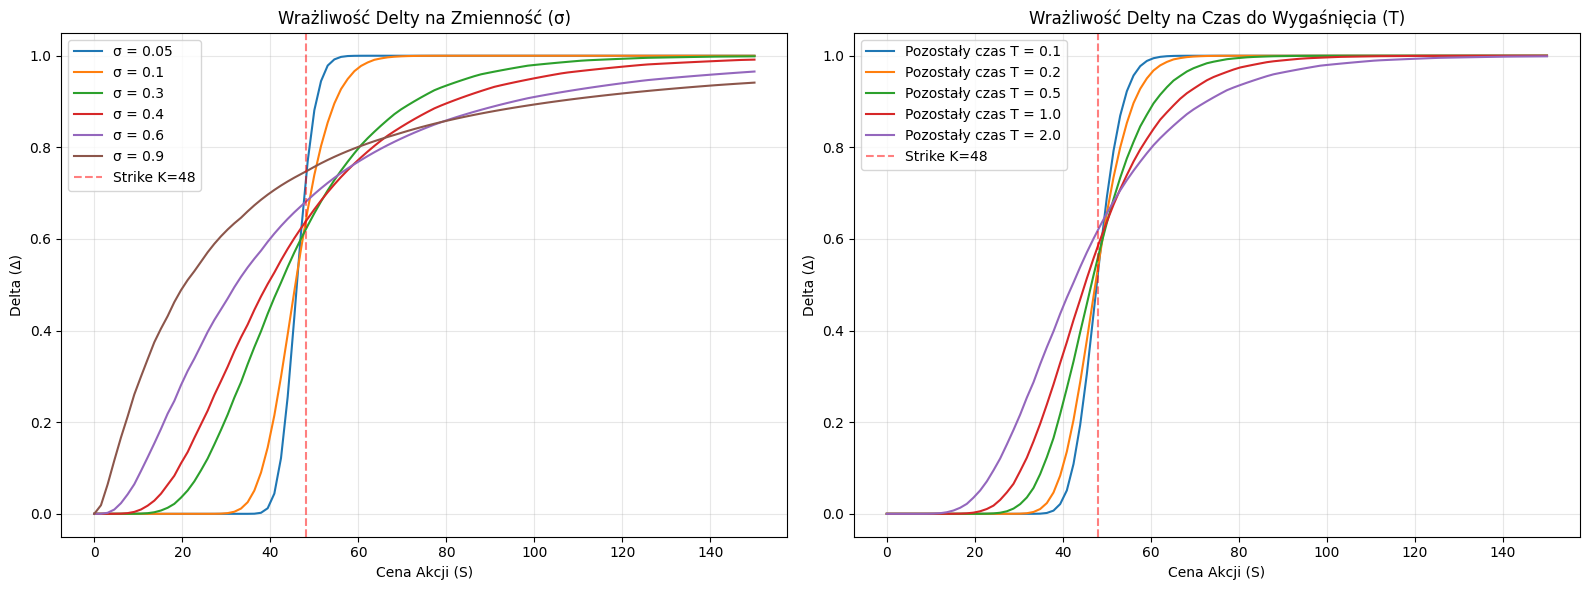

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_delta_sensitivities():
    S_range = np.linspace(0.01, 150, 100)
    
    K_val = 48
    r_val = 0.02
    T_total = 2.0
    N_steps = 50 
    dt_val = T_total / N_steps

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


    sigmas = [0.05,0.1, 0.3, 0.4, 0.6, 0.9]
    for s in sigmas:
        deltas = []
        u_s = np.exp(s * np.sqrt(dt_val))
        d_s = 1/u_s
        for s_val in S_range:
            # Tworzymy model dla konkretnego punktu S0
            temp_model = BinomialModel(s_val, N_steps, dt_val, u_s, d_s, r_val)
            opt = EuropeanCall(K_val)
            d_tree, _ = opt.price_with_hedging(temp_model)
            deltas.append(d_tree[0, 0]) # Pobieramy Deltę w chwili t=0
        
        ax1.plot(S_range, deltas, label=f'σ = {s}')

    ax1.set_title("Wrażliwość Delty na Zmienność (σ)")
    ax1.set_xlabel("Cena Akcji (S)")
    ax1.set_ylabel("Delta (Δ)")
    ax1.axvline(K_val, color='red', linestyle='--', alpha=0.5, label=f'Strike K={K_val}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)


    times_to_mat = [0.1,0.2, 0.5,1.0, 2.0] 
    sigma_fixed = 0.3
    
    for t_rem in times_to_mat:
        deltas = []
        dt_rem = t_rem / N_steps
        u_t = np.exp(sigma_fixed * np.sqrt(dt_rem))
        d_t = 1/u_t
        for s_val in S_range:
            temp_model = BinomialModel(s_val, N_steps, dt_rem, u_t, d_t, r_val)
            opt = EuropeanCall(K_val)
            d_tree, _ = opt.price_with_hedging(temp_model)
            deltas.append(d_tree[0, 0])
            
        ax2.plot(S_range, deltas, label=f'Pozostały czas T = {t_rem}')

    ax2.set_title("Wrażliwość Delty na Czas do Wygaśnięcia (T)")
    ax2.set_xlabel("Cena Akcji (S)")
    ax2.set_ylabel("Delta (Δ)")
    ax2.axvline(K_val, color='red', linestyle='--', alpha=0.5, label=f'Strike K={K_val}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_delta_sensitivities()

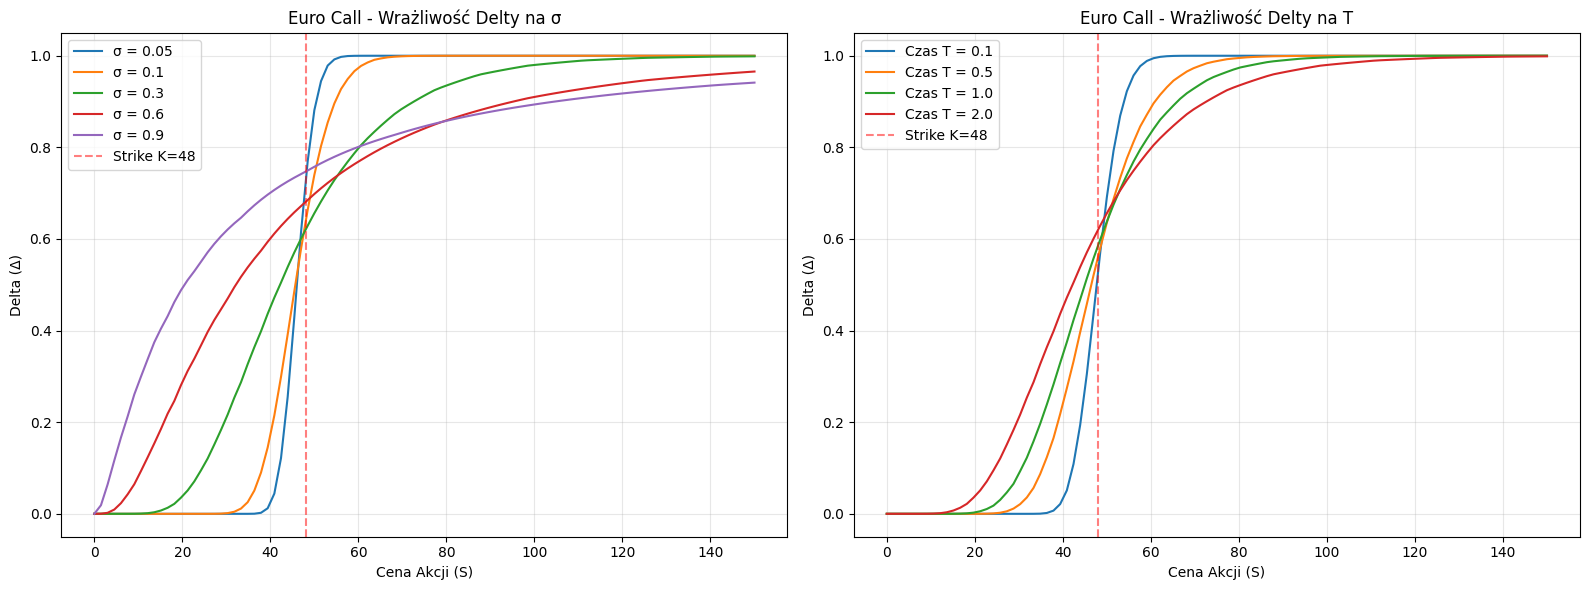

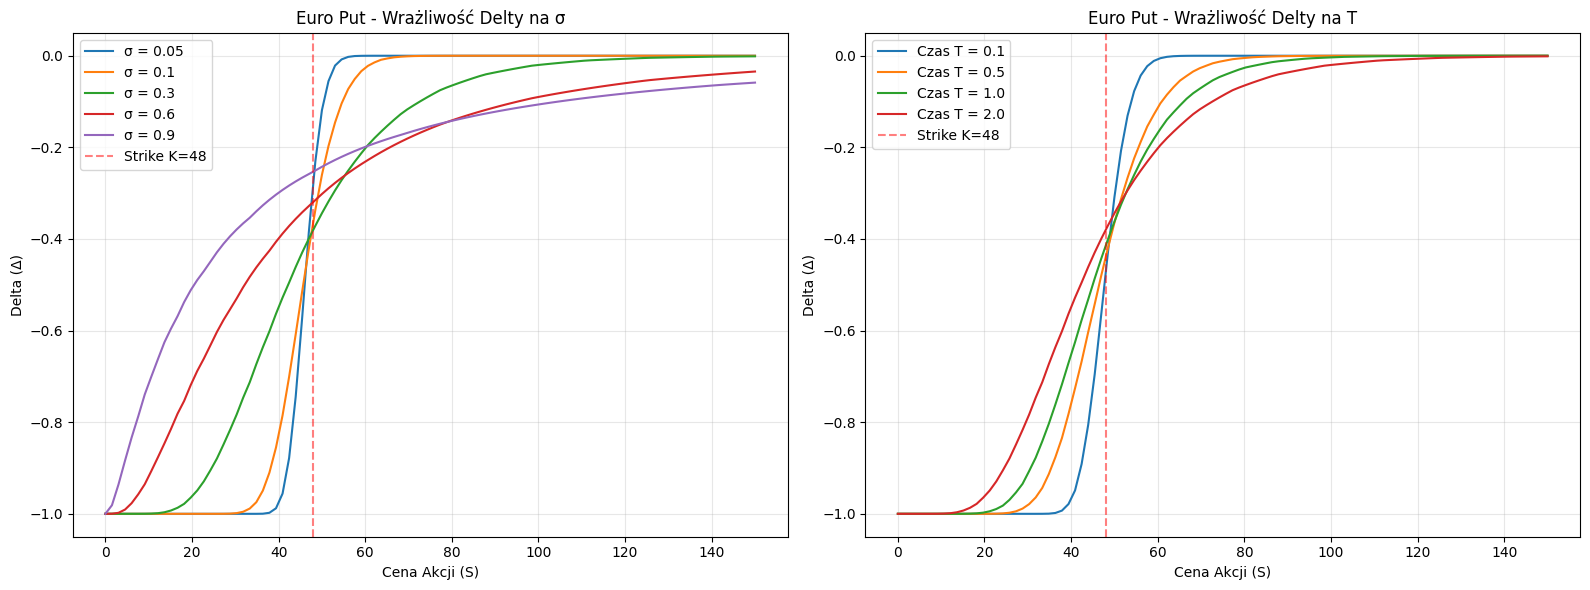

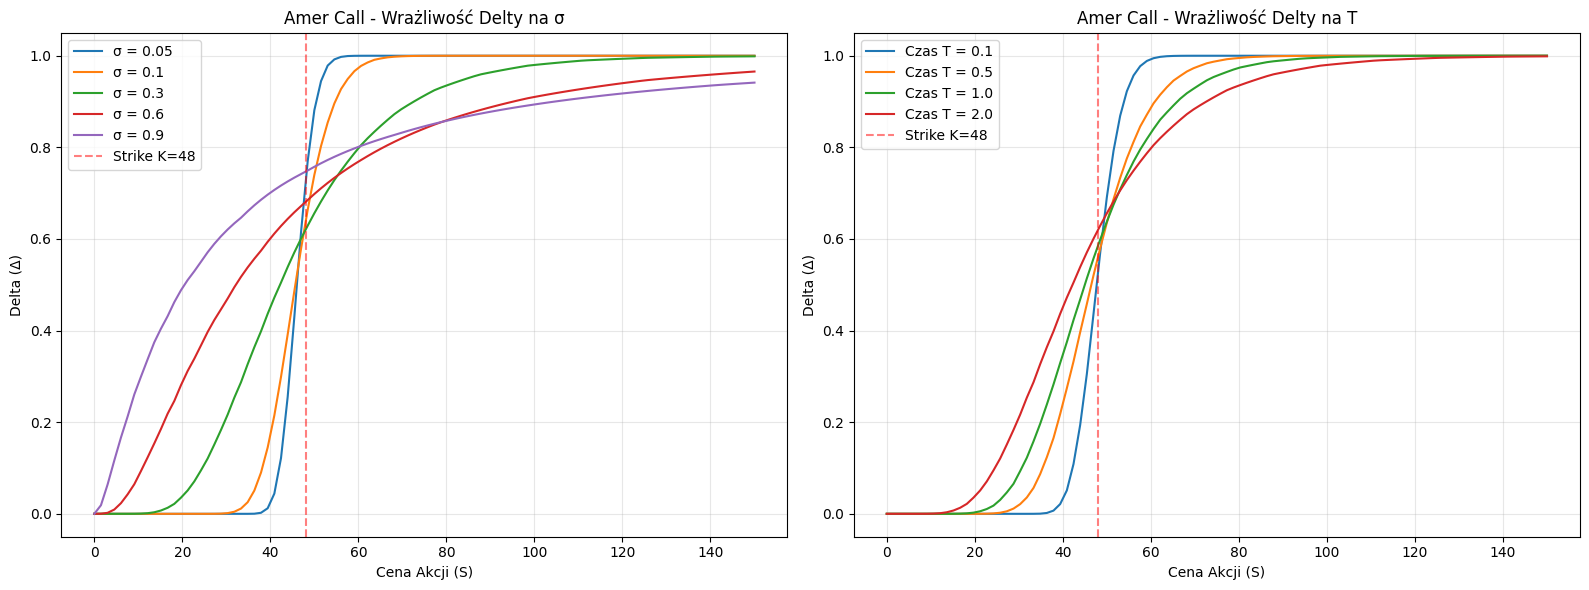

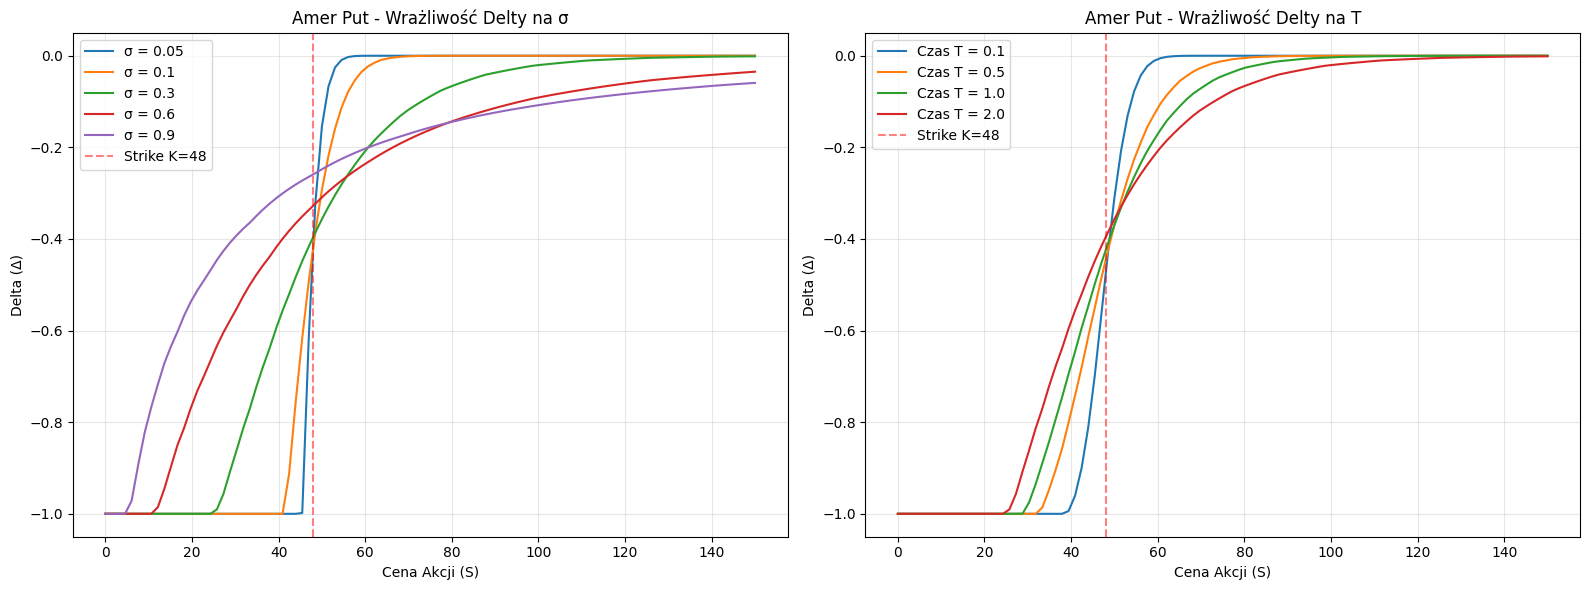

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_delta_sensitivities(option_type='Euro Call'):
    """
    option_type może przyjąć: 'Euro Call', 'Euro Put', 'Amer Call', 'Amer Put'
    """
    S_range = np.linspace(0.01, 150, 100)
    K_val = 48
    r_val = 0.02
    N_steps = 50 
    
    # Mapowanie typu opcji na klasy
    option_map = {
        'Euro Call': EuropeanCall,
        'Euro Put': EuropeanPut,
        'Amer Call': AmericanCall,
        'Amer Put': AmericanPut
    }
    
    OptionClass = option_map[option_type]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- WYKRES 1: WRAŻLIWOŚĆ NA ZMIENNOŚĆ (σ) ---
    T_fixed = 2.0
    dt_fixed = T_fixed / N_steps
    sigmas = [0.05, 0.1, 0.3, 0.6, 0.9]
    
    for s in sigmas:
        deltas = []
        u_s = np.exp(s * np.sqrt(dt_fixed))
        d_s = 1/u_s
        for s_val in S_range:
            temp_model = BinomialModel(s_val, N_steps, dt_fixed, u_s, d_s, r_val)
            opt = OptionClass(K_val)
            d_tree, _ = opt.price_with_hedging(temp_model)
            deltas.append(d_tree[0, 0])
        ax1.plot(S_range, deltas, label=f'σ = {s}')

    ax1.set_title(f"{option_type} - Wrażliwość Delty na σ")
    ax1.set_xlabel("Cena Akcji (S)")
    ax1.set_ylabel("Delta (Δ)")
    ax1.axvline(K_val, color='red', linestyle='--', alpha=0.5, label=f'Strike K={K_val}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- WYKRES 2: WRAŻLIWOŚĆ NA CZAS (T) ---
    sigma_fixed = 0.3
    times_to_mat = [0.1, 0.5, 1.0, 2.0] 
    
    for t_rem in times_to_mat:
        deltas = []
        dt_rem = t_rem / N_steps
        u_t = np.exp(sigma_fixed * np.sqrt(dt_rem))
        d_t = 1/u_t
        for s_val in S_range:
            temp_model = BinomialModel(s_val, N_steps, dt_rem, u_t, d_t, r_val)
            opt = OptionClass(K_val)
            d_tree, _ = opt.price_with_hedging(temp_model)
            deltas.append(d_tree[0, 0])
        ax2.plot(S_range, deltas, label=f'Czas T = {t_rem}')

    ax2.set_title(f"{option_type} - Wrażliwość Delty na T")
    ax2.set_xlabel("Cena Akcji (S)")
    ax2.set_ylabel("Delta (Δ)")
    ax2.axvline(K_val, color='red', linestyle='--', alpha=0.5, label=f'Strike K={K_val}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Wywołania dla wszystkich typów opcji:
types = ['Euro Call', 'Euro Put', 'Amer Call', 'Amer Put']
for t in types:
    plot_all_delta_sensitivities(t)

# czy da sie powiedziec cos wiecej o zależności kształtu option price od T dlaczego ona rośnie na początku troche, to że maleje to oczywiste - to wytłumaczyliśmy.

# czy da sięwyznaczyć linie rozdzielającą false od true w american pyt
# ulepszyć drzewo wizualizacyjne AMPUT
# podanie argumentów dla oblicznia 
# źródło oscylacji i czynniki powodujące oscylacje, dla zmiany deltaT 
# gra zależy od strike -> pokazać dla zmiany deltaT
# są scenariusze w których wykres tak nie wychodzi w zależności od strike i możę czegoś jeszcze
# delta hedging - dlaczego put AM zachowuje sie troche innaczej od put EU, porównać te wykresy warto mieć je obok siebie 